In [34]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from shadowroutes.config import settings
from shadowroutes.model.abm import Model

sns.set(style="whitegrid")

src_path = Path('../')
os.chdir(src_path)

## Parameters

In [54]:
# Paths
env_panel_path = Path(settings.DATA_ROOT / 'processed' / 'environment_panel.csv')
crime_panel_path = Path(settings.DATA_ROOT / 'processed' / 'crime_panel.csv')
adjacency_nodes_path = Path(settings.DATA_ROOT / 'processed' / 'adjacency_nodes.csv')

# Output
images_path = Path(settings.DATA_ROOT / 'outputs')

## Data

In [3]:
env_panel = pd.read_csv(env_panel_path, encoding='utf-8', dtype={"muni_id": str})
print(f'File read: {print(env_panel_path.name)}')

print(env_panel.shape)
env_panel.head()

environment_panel.csv
File read: None
(323, 11)


,muni_id,state_id,municipality,geometry,year,state,pop_total,prot_idx,mining_idx,collusion_idx,node_id
0,12033,12,Huamuxtitlán,"POLYGON ((-98.4724366200569 17.97081319957666,...",2025,Guerrero,18207,0.342432,0.000000,0.592026,12033
1,12031,12,General Canuto A. Neri,POLYGON ((-100.0758836904194 18.54482622990908...,2025,Guerrero,6913,0.103911,0.698605,0.592026,12031
2,12083,12,Ñuu Savi,POLYGON ((-98.97828861090657 17.01672138920664...,2025,Guerrero,11563,0.000000,0.000000,0.592026,12083
3,12082,12,Las Vigas,POLYGON ((-99.23351249962433 16.82400111020028...,2025,Guerrero,10136,0.000000,0.000000,0.592026,12082
4,12073,12,Zirándaro,POLYGON ((-101.2816862298956 18.54467114962441...,2025,Guerrero,18026,0.138348,0.826372,0.592026,12073


In [4]:
env_panel.dtypes

muni_id           object
state_id           int64
municipality      object
geometry          object
year               int64
state             object
pop_total          int64
prot_idx         float64
mining_idx       float64
collusion_idx    float64
node_id            int64
dtype: object

In [5]:
env_panel['muni_id'] = env_panel['muni_id'].astype('str')
env_panel['node_id'] = env_panel['node_id'].astype('str')

In [6]:
crime_panel = pd.read_csv(crime_panel_path, encoding='utf-8', dtype={"muni_id": str})
print(f'File read: {print(crime_panel_path.name)}')

print(crime_panel.shape)
crime_panel.head()

crime_panel.csv
File read: None
(41606, 13)


,year,month,state_id,state,muni_id,municipality,extortion_rate,homicide_rate,drug_dealing_rate,kidnapping_rate,human_trafficking_rate,t,violence_idx
0,2015,1,12,Guerrero,12001,Acapulco de Juárez,0.6,4.2,3.9,0.0,0.0,0,0.040849
1,2015,1,12,Guerrero,12002,Ahuacuotzingo,0.0,0.0,0.0,0.0,0.0,0,0.000000
2,2015,1,12,Guerrero,12003,Ajuchitlán del Progreso,0.0,2.6,0.0,2.6,0.0,0,0.030002
3,2015,1,12,Guerrero,12004,Alcozauca de Guerrero,0.0,0.0,0.0,0.0,0.0,0,0.000000
4,2015,1,12,Guerrero,12005,Alpoyeca,0.0,14.5,0.0,0.0,0.0,0,0.100392


In [7]:
crime_panel.dtypes

year                        int64
month                       int64
state_id                    int64
state                      object
muni_id                    object
municipality               object
extortion_rate            float64
homicide_rate             float64
drug_dealing_rate         float64
kidnapping_rate           float64
human_trafficking_rate    float64
t                           int64
violence_idx              float64
dtype: object

In [8]:
crime_panel['muni_id'] = crime_panel['muni_id'].astype('str')

In [9]:
edges = pd.read_csv(adjacency_nodes_path, encoding='utf-8', dtype={"source": str, "target": str})
print(f'File read: {print(adjacency_nodes_path.name)}')

print(edges.shape)
edges.head()

adjacency_nodes.csv
File read: None
(859, 2)


,source,target
0,12033,12066
1,12033,12005
2,12033,12024
3,12033,12045
4,12033,12070


In [10]:
edges['source'] = edges['source'].astype('str')
edges['target'] = edges['target'].astype('str')

## Execute model

#### Test crime slice

In [11]:
from shadowroutes.model.env import build_env_graph, get_crime_slice, update_env_from_crime

G = build_env_graph(env_panel, edges)
degree_hist = [d for n,d in G.degree()]

print((min(degree_hist), max(degree_hist), sum(degree_hist)/len(degree_hist)))

crime_t0 = get_crime_slice(crime_panel, t=5)
update_env_from_crime(G, crime_t0)

# Inspect one node
some_node = list(G.nodes)[0]
G.nodes[some_node]


(1, 14, 5.318885448916409)


{'muni_id': '12033',
 'state_id': 12,
 'state': 'Guerrero',
 'municipality': 'Huamuxtitlán',
 'pop_total': 18207,
 'prot_idx': 0.3424323977957196,
 'mining_idx': 0.0,
 'collusion_idx': 0.5920264574256163,
 'extortion_rate': 0.0,
 'homicide_rate': 6.3,
 'drug_dealing_rate': 0.0,
 'kidnapping_rate': 0.0,
 'human_trafficking_rate': 0.0,
 'violence': 0.0436187399030694}

## Instantiate model

In [12]:
print(f'{crime_panel.t.min()}, {crime_panel.t.max()}')

0, 129


In [13]:
# Instantiate
t_min=0
t_max=129

m = Model(
    munis_df=env_panel,
    edges_df=edges,
    crime_panel=crime_panel,
    start_t=t_min,
    end_t=t_max,
    n_ocg=6,
    civ_per_muni=10,
)

# Run
m.run()

In [35]:
ts = m.datacollector.get_model_vars_dataframe()

### Results check

In [36]:
# Total displacement flows recorded - only last tick
flows = m._flows
flows

[]

In [37]:
# Collect data
ts.tail()

,t,violence_mean,contested_munis,displacement_flows
125,125,0.013863,2,0
126,126,0.012445,2,0
127,127,0.011511,2,0
128,128,0.012543,2,0
129,129,0.000619,2,0


In [16]:
from shadowroutes.model.agents import CivilianAgent

# After one run, or even after one step()
sample = []
for agent in m.scheduler.agents:
    if isinstance(agent, CivilianAgent) and agent.muni_id != "SINK":
        node = m.G.nodes[agent.muni_id]
        base_v = node["violence"]
        rivals = max(m.ocg_presence_count(agent.muni_id) - 1, 0)
        protection = node["prot_idx"] * (1 - node["collusion_idx"])
        perceived = 2.0 * base_v + 0.8 * rivals - 0.2 * protection
        sample.append((perceived, agent.risk_threshold))

perceived_vals = np.array([p for p, th in sample])
th_vals = np.array([th for p, th in sample])

perceived_vals.min(), perceived_vals.max(), th_vals.min(), th_vals.max()


(np.float64(-0.09195836452631928),
 np.float64(0.08645675989003677),
 np.float64(0.40008485773916824),
 np.float64(0.8998028734056731))

In [17]:
# Inspect risk vs threshold for a sample of civilians after the last step

civ_agents = [a for a in m.scheduler.agents if a.unique_id.startswith("civ_")]

vals = []
for a in civ_agents[:2000]:  # sample if you want
    if a.muni_id == "SINK":
        continue
    node = m.G.nodes[a.muni_id]
    base_v = a._base_violence(node)
    rivals = max(m.ocg_presence_count(a.muni_id) - 1, 0)
    protection = node.get("prot_idx", 0.0) * (1.0 - node.get("collusion_idx", 0.0))
    perceived = 2 * base_v + 0.8 * rivals - 0.3 * protection
    vals.append((perceived, a.risk_threshold))

perceived_vals = np.array([v[0] for v in vals])
thr_vals = np.array([v[1] for v in vals])

print("mean perceived:", perceived_vals.mean())
print("mean threshold:", thr_vals.mean())
print("share perceived > threshold:", (perceived_vals > thr_vals).mean())


mean perceived: -0.03554562598074845
mean threshold: 0.6553364365113061
share perceived > threshold: 0.0


In [21]:
flows_df = pd.DataFrame(m._flows_history, columns=["t", "origin", "dest"])
flows_df["is_sink"] = flows_df["dest"] == "SINK"
flows_df["origin"] = flows_df["origin"].astype(str)

# Lookup table for muni_id -> (state, municipality)
munis_lookup = (
    env_panel.drop_duplicates(subset=["muni_id"])
             .set_index("muni_id")[["state", "municipality"]]
)

flows_df["state"] = flows_df["origin"].map(munis_lookup["state"])
flows_df["municipality_name"] = flows_df["origin"].map(munis_lookup["municipality"])

print(flows_df["is_sink"].value_counts())
print(flows_df.shape)
print(flows_df.head())

is_sink
False    84
Name: count, dtype: int64
(84, 6)
   t origin   dest  is_sink     state     municipality_name
0  0  12054  12011    False  Guerrero  San Miguel Totolapan
1  0  12054  12011    False  Guerrero  San Miguel Totolapan
2  0  12054  12011    False  Guerrero  San Miguel Totolapan
3  0  12054  12011    False  Guerrero  San Miguel Totolapan
4  0  12054  12011    False  Guerrero  San Miguel Totolapan


In [22]:
# Aggregate: where are flows coming from, and how many?
flows_agg = (
        flows_df.groupby(["state", "municipality_name", "origin"])
                .size()
                .reset_index(name="num_flows")
                .sort_values("num_flows", ascending=False)
    )

flows_agg.head(20)

,state,municipality_name,origin,num_flows
0,Guerrero,Acapulco de Juárez,12001,10
1,Guerrero,Chilpancingo de los Bravo,12029,10
6,Guerrero,Zihuatanejo de Azueta,12038,10
5,Guerrero,San Miguel Totolapan,12054,7
7,Guerrero,Zitlala,12074,7
9,Michoacán de Ocampo,Chinicuila,16026,6
11,Michoacán de Ocampo,Cojumatlán de Régules,16074,5
3,Guerrero,Juchitán,12080,4
19,Michoacán de Ocampo,Zináparo,16109,4
17,Michoacán de Ocampo,Tocumbo,16095,3


In [25]:
# Check how violent the sources are

orig_ids = flows_agg["origin"].unique()
orig_env = env_panel[env_panel["muni_id"].isin(orig_ids)][
    ["muni_id", "state", "municipality", "prot_idx", "mining_idx", "collusion_idx"]
].drop_duplicates()

# At a chosen time t, say t=11
crime_t11 = get_crime_slice(crime_panel, t=11).reset_index()

orig_summary = orig_env.merge(crime_t11, on="muni_id", how="left")
orig_summary.head()


,muni_id,state,municipality,prot_idx,mining_idx,collusion_idx,extortion_rate,homicide_rate,drug_dealing_rate,kidnapping_rate,human_trafficking_rate,violence_idx
0,12054,Guerrero,San Miguel Totolapan,0.089007,0.937970,0.592026,0.0,0.0,3.5,0.0,0.0,0.008078
1,12029,Guerrero,Chilpancingo de los Bravo,0.083845,0.906082,0.628939,0.7,9.3,1.4,0.4,0.0,0.072698
2,12038,Guerrero,Zihuatanejo de Azueta,0.355276,0.852267,0.544957,0.0,3.1,0.0,0.0,0.0,0.021463
3,12001,Guerrero,Acapulco de Juárez,0.104702,0.715692,0.783212,0.7,8.9,2.1,0.4,0.0,0.071544
4,12074,Guerrero,Zitlala,0.000000,0.576831,0.592026,0.0,0.0,0.0,0.0,0.0,0.000000


In [18]:
#node = "12033"  # Huamuxtitlán, an accidental peaceful utopia (maybe)
#m.G.nodes[node]

In [19]:
#node = "12001"  # Acapulco de Juárez
#m.G.nodes[node]

### Visualizations

#### Data to plot

In [39]:
flows_df = pd.DataFrame(m._flows_history, columns=["t", "origin", "dest"])
flows_df["is_sink"] = flows_df["dest"] == "SINK"
flows_df["origin"] = flows_df["origin"].astype(str)
flows_df["dest"] = flows_df["dest"].astype(str)


In [41]:
# Lookup for names
muni_lookup = (
    env_panel.drop_duplicates(subset=["muni_id"])
             .set_index("muni_id")[["state", "municipality"]]
)

# Aggregate by origin and by dest
flows_by_origin = (
    flows_df.groupby("origin")
            .size()
            .reset_index(name="num_flows")
            .sort_values("num_flows", ascending=False)
)

flows_by_dest = (
    flows_df[~flows_df["is_sink"]]   # ignore SINK for destinations
            .groupby("dest")
            .size()
            .reset_index(name="num_flows")
            .sort_values("num_flows", ascending=False)
)

# Attach names
flows_by_origin["state"] = flows_by_origin["origin"].map(muni_lookup["state"])
flows_by_origin["municipality"] = flows_by_origin["origin"].map(muni_lookup["municipality"])

flows_by_dest["state"] = flows_by_dest["dest"].map(muni_lookup["state"])
flows_by_dest["municipality"] = flows_by_dest["dest"].map(muni_lookup["municipality"])

top_n = 10
top_orig = flows_by_origin.head(top_n)
top_dest = flows_by_dest.head(top_n)


In [43]:
crime_cols = [
    "extortion_rate",
    "homicide_rate",
    "drug_dealing_rate",
    "kidnapping_rate",
    "human_trafficking_rate",
]

top_origin_ids = top_orig["origin"].tolist()
top_dest_ids   = top_dest["dest"].tolist()

# Filter crime panel
orig_crime = crime_panel[crime_panel["muni_id"].isin(top_origin_ids)]
dest_crime = crime_panel[crime_panel["muni_id"].isin(top_dest_ids)]

# Average over time within group
orig_ts = orig_crime.groupby("t")[crime_cols].mean().reset_index()
dest_ts = dest_crime.groupby("t")[crime_cols].mean().reset_index()

# Global means across all muni,t
global_means = crime_panel[crime_cols].mean()


In [59]:
# 1) Average violence per municipality over time
violence_muni = (
    crime_panel
    .groupby("muni_id")["violence_idx"]
    .mean()
    .reset_index()
)

# 2) Identify top origin/destination sets
top_origin_ids = top_orig["origin"].astype(str).tolist()
top_dest_ids   = top_dest["dest"].astype(str).tolist()

violence_muni["muni_id"] = violence_muni["muni_id"].astype(str)

# 3) Add group label
conditions = [
    violence_muni["muni_id"].isin(top_origin_ids),
    violence_muni["muni_id"].isin(top_dest_ids),
]
choices = ["Top origins", "Top destinations"]

violence_muni["group"] = np.select(
    conditions,
    choices,
    default="All municipalities"
)

# 4) Attach names
muni_lookup = (
    env_panel.drop_duplicates(subset=["muni_id"])
             .assign(muni_id=lambda d: d["muni_id"].astype(str))
             .set_index("muni_id")[["state", "municipality"]]
)

violence_muni["state"] = violence_muni["muni_id"].map(muni_lookup["state"])
violence_muni["municipality"] = violence_muni["muni_id"].map(muni_lookup["municipality"])

#### Plots

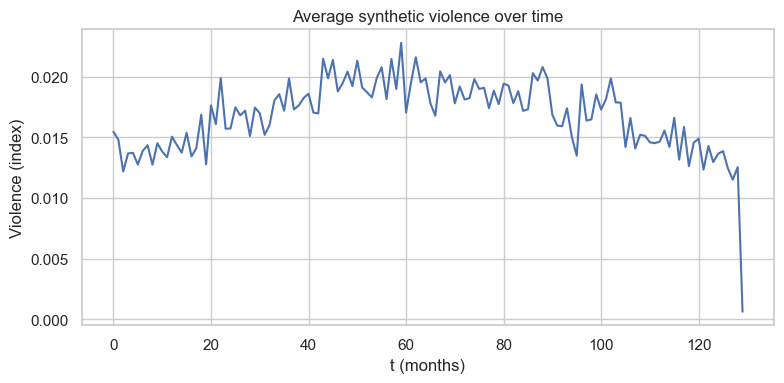

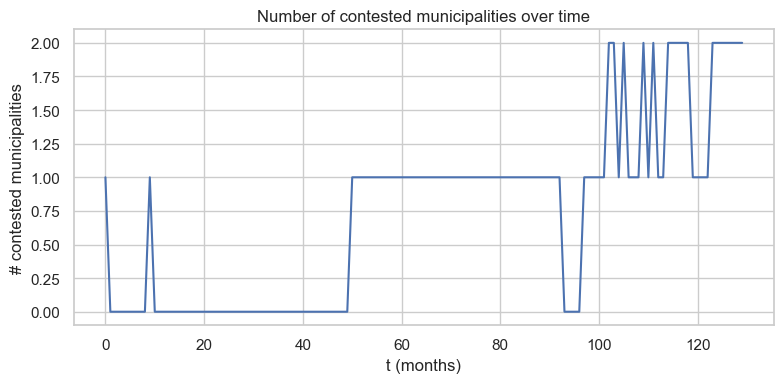

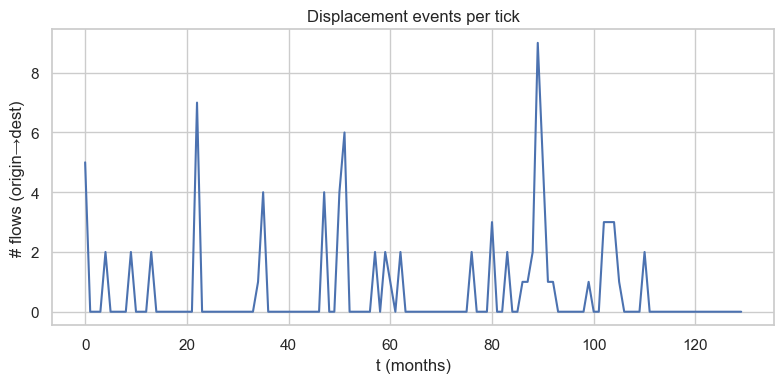

In [56]:
# a) Violence over time
plt.figure(figsize=(8,4))
sns.lineplot(data=ts, x="t", y="violence_mean")
plt.title("Average synthetic violence over time")
plt.xlabel("t (months)")
plt.ylabel("Violence (index)")
plt.tight_layout()

plt.savefig(images_path / "avg_synth_violence.png" , dpi=200)

# b) Contested municipalities
plt.figure(figsize=(8,4))
sns.lineplot(data=ts, x="t", y="contested_munis")
plt.title("Number of contested municipalities over time")
plt.xlabel("t (months)")
plt.ylabel("# contested municipalities")
plt.tight_layout()

plt.savefig(images_path / "contested_municipalities.png" , dpi=200)

# c) Displacement flows
plt.figure(figsize=(8,4))
sns.lineplot(data=ts, x="t", y="displacement_flows")
plt.title("Displacement events per tick")
plt.xlabel("t (months)")
plt.ylabel("# flows (origin→dest)")
plt.tight_layout()

plt.savefig(images_path / "displacement_events.png" , dpi=200)


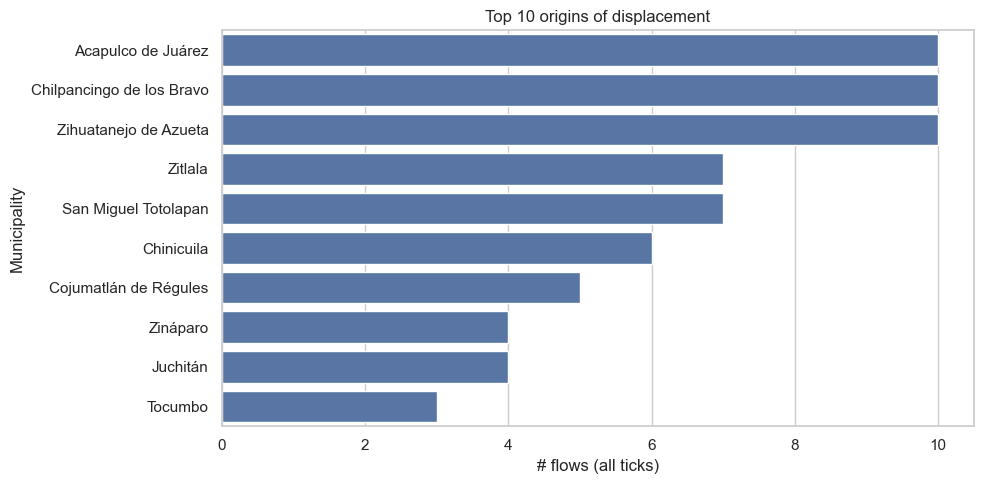

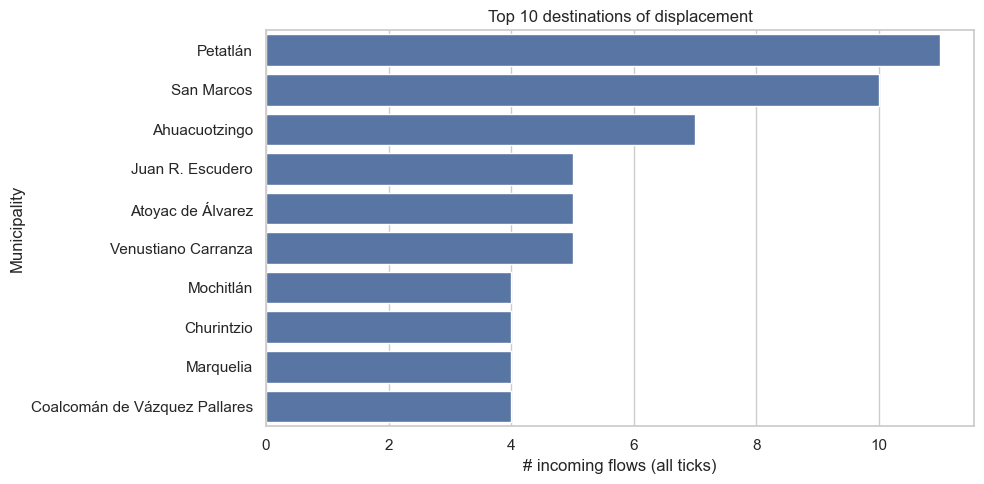

In [57]:
# Origin barplot
plt.figure(figsize=(10,5))
sns.barplot(
    data=top_orig,
    x="num_flows",
    y="municipality",
    orient="h"
)
plt.title(f"Top {top_n} origins of displacement")
plt.xlabel("# flows (all ticks)")
plt.ylabel("Municipality")
plt.tight_layout()

plt.savefig(images_path / "top_origins_displacement.png" , dpi=200)

# Destination barplot
plt.figure(figsize=(10,5))
sns.barplot(
    data=top_dest,
    x="num_flows",
    y="municipality",
    orient="h"
)
plt.title(f"Top {top_n} destinations of displacement")
plt.xlabel("# incoming flows (all ticks)")
plt.ylabel("Municipality")
plt.tight_layout()

plt.savefig(images_path / "top_destinations_displacement.png" , dpi=200)


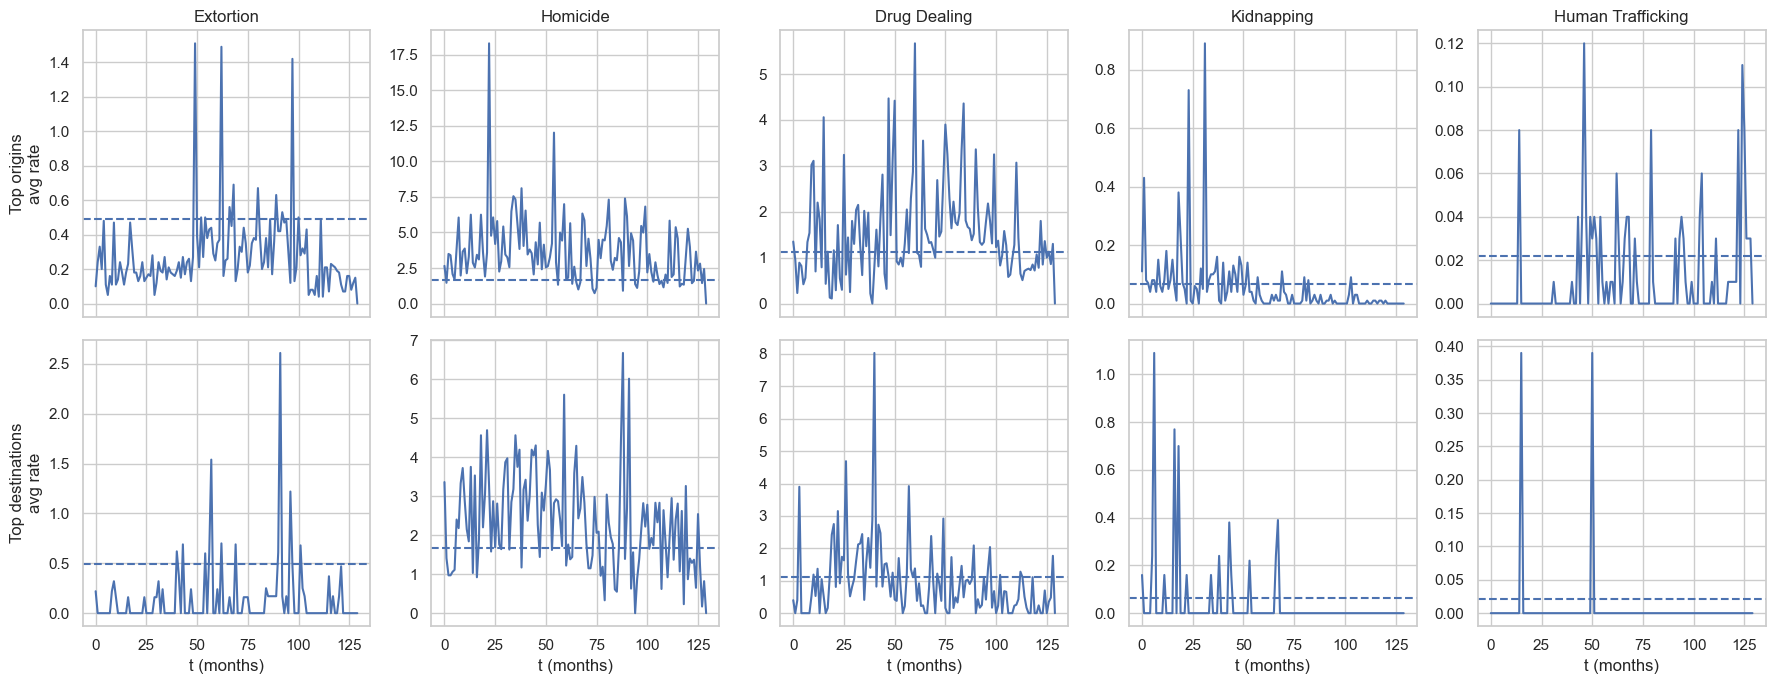

In [58]:
fig, axes = plt.subplots(
    nrows=2, ncols=len(crime_cols),
    figsize=(18, 7),
    sharex=True
)

for j, col in enumerate(crime_cols):
    # Top origins
    ax = axes[0, j]
    sns.lineplot(data=orig_ts, x="t", y=col, ax=ax)
    ax.axhline(global_means[col], linestyle="--")
    ax.set_title(col.replace("_rate", "").replace("_", " ").title())
    if j == 0:
        ax.set_ylabel("Top origins\navg rate")
    else:
        ax.set_ylabel("")

    # Top destinations
    ax2 = axes[1, j]
    sns.lineplot(data=dest_ts, x="t", y=col, ax=ax2)
    ax2.axhline(global_means[col], linestyle="--")
    if j == 0:
        ax2.set_ylabel("Top destinations\navg rate")
    else:
        ax2.set_ylabel("")
    ax2.set_xlabel("t (months)")

plt.tight_layout()

plt.savefig(images_path / "crime_rates_top_origins_destinations.png" , dpi=200)


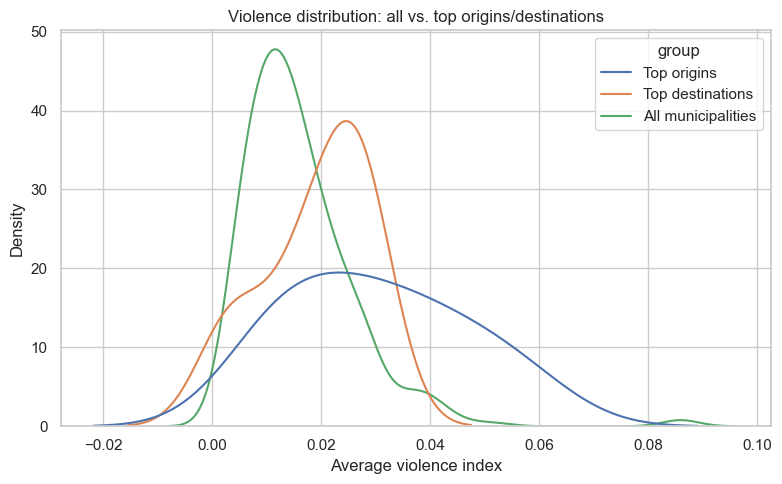

In [62]:
# 6) If you want overlaid KDEs instead of facets:
plt.figure(figsize=(8,5))
sns.kdeplot(
    data=violence_muni,
    x="violence_idx",
    hue="group",
    common_norm=False
)
plt.xlabel("Average violence index")
plt.ylabel("Density")
plt.title("Violence distribution: all vs. top origins/destinations")
plt.tight_layout()

plt.savefig(images_path / "distr_avg_violence_idx.png" , dpi=200)